# alternating soundsource analysis

In [1]:
from workbench.data.preprocess import combTableCreate, expand_dict_columns
from workbench.plotting import serve_cell_dashboard
import numpy as np
import pandas as pd
import polars as pl
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import panel as pn
from scipy.stats import friedmanchisquare, wilcoxon, false_discovery_control
from scipy.ndimage import gaussian_filter1d
from scipy.stats import gaussian_kde
import itertools
import matplotlib.pyplot as plt
%matplotlib inline

individuals_flag = False

In [2]:
conn = sqlite3.connect(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\Recordings_FH.db")
sql = """
SELECT * FROM Recordings WHERE (Animal_Id, Cell_Id) IN (
SELECT Animal_Id, Cell_Id FROM Recordings WHERE Condition IN ("Baseline", "soso") GROUP BY Animal_Id, Cell_Id 
HAVING COUNT(DISTINCT Condition) >= 2) 
AND Condition IN ("Baseline","soso") AND use = 1 AND Folders_generated = 1
"""

datatable= pd.read_sql_query(sql, conn)
conn.close()

In [3]:
try:
    comb_table = pl.read_parquet(Path(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\comb_tables\soso_comb.parquet"))
except:
    print('comb_table doesnt exist, start creation')
    comb_table = combTableCreate(datatable)
    comb_df = pd.DataFrame(comb_table)
    dict_list = [ 'pupil_psth', 'whisk_psth', 'eye_psth']
    comb_df = expand_dict_columns(
        comb_df,
        dict_columns=dict_list,
        flatten_2d=False
    )
    # clean and reshape the dataframe
    comb_table = pl.from_dataframe(comb_df)
    conditions = comb_table['Condition'].unique().to_list()

    comb_a = (
        comb_table.filter(pl.col("Condition") == conditions[0]).drop("Condition")
    )
    comb_b = (
        comb_table.filter(pl.col("Condition") == conditions[1]).drop("Condition")
    )

    comb_joined = comb_a.join(
        comb_b,
        on=['Animal_Id', 'Cell_Id'],
        how="inner"
    )

    comb_joined = comb_joined[[s.name for s in comb_joined if not (s.null_count() == comb_joined.height)]]
    comb_table = comb_joined.rename(lambda c: c[:-6] if c.endswith("_right") else c)
    comb_table.write_parquet(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\comb_tables\soso_comb.parquet", use_pyarrow=True)
    print("table created and saved")

In [4]:
# analysis
speaker_position = {
    'a': 93,
    'w': 178,
    'e': 272,
    'r': 356
}
rads_x = np.cos(np.deg2rad(list(speaker_position.values())))
rads_y = np.sin(np.deg2rad(list(speaker_position.values())))
#returned_degs = np.degrees(np.arctan2(rads_y, rads_x))
#returned_degs = (returned_degs+360)%360


For the analysis i should start with per recording representation of activity per speaker position. What about Rasterplots stacked on top of each other (4), each corresponding to a different speaker.
For now this will happen for all recordings individually before analysis across all follows

In [5]:
# cell by cell sound source representation

half_window = 1500 # in ms
time_bin = 0.002
nbins = int(np.round(half_window/(time_bin*1000)))
raster_edges = np.linspace(-half_window, half_window, nbins*2+1)

# mimic the medfilt1
bins_plot = np.concatenate(
    [[raster_edges[0]],
      np.median(
          np.vstack( # create a 2d array with the raster edges shifted by 1 each. the median then picks the value right in between them
              [raster_edges[:-1],
                raster_edges[1:]]
                )
            , axis=0)
    ]
)
bins_plot = bins_plot[1::]
resp_window = np.flatnonzero(
        (bins_plot > 1) & (bins_plot < 300)
        )

speakers = ["a", "w", "e", "r"]
raster_times = comb_table['RasterTimes']
raster_rows = comb_table['RasterRows']
raster_rate = comb_table['RasterRate']
HDRateSmooth = comb_table['hdRateSmooth']
DIRECTIONS = np.linspace(0, 360, 37)
stim_keys = raster_times[0].keys()
trigger_time = np.array(comb_table['trigger_time'][0].to_list())
time_pre = (trigger_time < 0) & (trigger_time >=-0.5)
whisk_psth = {
    "a": comb_table['whisk_psth_a'],
    "w": comb_table["whisk_psth_w"],
    "e": comb_table["whisk_psth_e"],
    "r": comb_table["whisk_psth_r"]
}
new_rate = np.zeros((len(raster_times), len(raster_edges)-1, len(stim_keys)))
# reshape to array
whisk_avg_orig = np.array(comb_table['whisk_avg'].to_list())

whisk_avg = np.stack([
    np.stack([cell[k] for k in stim_keys], axis = 1)
    for cell in whisk_avg_orig
], axis=0)

zs_whisk = np.empty_like(whisk_avg)



In [6]:

for i in range(len(raster_times)):
    for idx, j in enumerate(stim_keys):
        if not len(raster_times[i][j]) == 0:
            counts, _ = np.histogram(raster_times[i][j], bins=raster_edges)
            new_rate[i, :, idx] = np.divide(counts, (np.max(raster_rows[i][j])*time_bin))
        

for idx, stim in enumerate(stim_keys):
    baseline = whisk_avg[:, trigger_time<=0, idx]
    mean_ = np.nanmean(baseline, axis=1, keepdims=True)
    std_ = np.nanstd(baseline, axis=1, keepdims=True)

    zs_whisk[:,:,idx] = (whisk_avg[:,:,idx] - mean_)/std_


In [7]:


# construct whisking
#with PdfPages(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\soundsource_switching\individuals.pdf") as pdf:

speaker_position = {
    "a": 93,
    "w": 178,
    "e": 272,
    "r": 356,
}

# Your mosaic layout (4 rows × 4 columns)
layout = [
    ["r_a", "psth_a", "line_a", "polar"],
    ["r_w", "psth_w", "line_w", "info"    ],
    ["r_e", "psth_e", "line_e", "info"    ],
    ["r_r", "psth_r", "line_r", "."    ],
]


# ─────────────────────────────────────────────────────────────
#  MAIN LOOP: one page per cell
# ─────────────────────────────────────────────────────────────
if individuals_flag:
    with PdfPages(r"\\172.25.250.112\burgalossi\lab share\Data\Florian\figures\py_soso_indiv_cells.pdf") as pdf:
        for row_idx in range(len(raster_rate)):

            fig, axd = plt.subplot_mosaic(
                layout,
                figsize=(15, 12),
                gridspec_kw={"width_ratios": [2.5, 3, 3, 2.5]},
                empty_sentinel=".",       # treat "." cells as empty
            )

            # ----------------------------------------------------------
            # Convert the placeholder "polar" axis into a real polar axes
            # ----------------------------------------------------------
            polar_spec = axd["polar"].get_subplotspec()
            axd["polar"].remove()
            ax_polar = fig.add_subplot(polar_spec, projection="polar")

            # ----------------------------------------------------------
            # Loop over speakers and fill rasters, PSTHs, lineplots
            # ----------------------------------------------------------

            tmin, tmax = -100, 500   # example x-range (adjust as needed)

            for enum, key in enumerate(speakers):
                # Named axes from the mosaic
                ax_r = axd[f"r_{key}"]
                ax_p = axd[f"psth_{key}"]
                ax_l = axd[f"line_{key}"]

                # Set x-limits for all time-based axes
                for ax in (ax_r, ax_p, ax_l):
                    ax.set_xlim(tmin, tmax)

                # ---------------- RASTER PLOT ----------------
                ax_r.scatter(
                    raster_times[row_idx][key],
                    raster_rows[row_idx][key],
                    marker=".",
                )
                ax_r.set_ylabel(f"Speaker position {speaker_position[key]} [°]",fontsize=12, weight='bold')

                # ---------------- PSTH PLOT ------------------
                ax_p.bar(bins_plot, new_rate[row_idx, :, enum], width=time_bin*1000, align='edge', edgecolor='none')
                ax_p.set_ylabel("Firing Rate [Hz]")

                # ---------------- LINE PLOT ------------------
                # median baseline subtract the response
                ax_l.plot(trigger_time*1000, zs_whisk[row_idx, :, enum])

            # ----------------------------------------------------------
            # Despine + tidy Cartesian axes
            # ----------------------------------------------------------

            def despine(ax):
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

            for key in speakers:
                despine(axd[f"r_{key}"])
                despine(axd[f"psth_{key}"])
                despine(axd[f"line_{key}"])

                # Cleaner PSTH/line look (optional):
                #axd[f"psth_{key}"].tick_params(axis="y", left=False, labelleft=False)
                #axd[f"line_{key}"].tick_params(axis="y", left=False, labelleft=False)

            # ----------------------------------------------------------
            # POLAR PLOT: mark speaker angles & plot tuning (optional)
            # ----------------------------------------------------------

            angles_deg = list(speaker_position.values())
            labels     = list(speaker_position.keys())
            angles_rad = np.deg2rad(angles_deg)

            # Angle grid with labels a/w/e/r
            ax_polar.set_thetagrids(angles_deg, angles_deg)
            ax_polar.plot(np.deg2rad(DIRECTIONS), HDRateSmooth[row_idx])

            # Optional: put markers at those angles (radius = 1)
            ax_polar.scatter(angles_rad, np.ones(len(angles_rad)), s=40)

            # Optional tuning curve:
            # rate = np.array([...])   # length 4, matching angles_deg
            # ax_polar.plot(angles_rad, rate)

            ax_info = axd['info']
            ax_info.axis('off')
            infotext = f"""
                            Animal:      {comb_table['Animal_Id'][row_idx]}
                            Cell:        {comb_table['Cell_Id'][row_idx]}
                            PD:          {comb_table['HDAngle'][row_idx]:.2f}
                            PeakFR:      {comb_table['HDpeakFR'][row_idx]:.2f}
                            MeanFR:      {comb_table['HDFR'][row_idx]:.2f}
                            HDInx:       {comb_table['HDInx'][row_idx]:.2f}
                            pValR:       {comb_table['pValR'][row_idx]:.2f}
                            binsize:     {1000*time_bin:.2f} ms
                        """

            ax_info.text(0,1, infotext, va='top')
            # ----------------------------------------------------------
            # Final layout touch
            # ----------------------------------------------------------
            fig.tight_layout()

            # If saving to PDF:
            pdf.savefig(fig)
            plt.close(fig)
    plt.show()

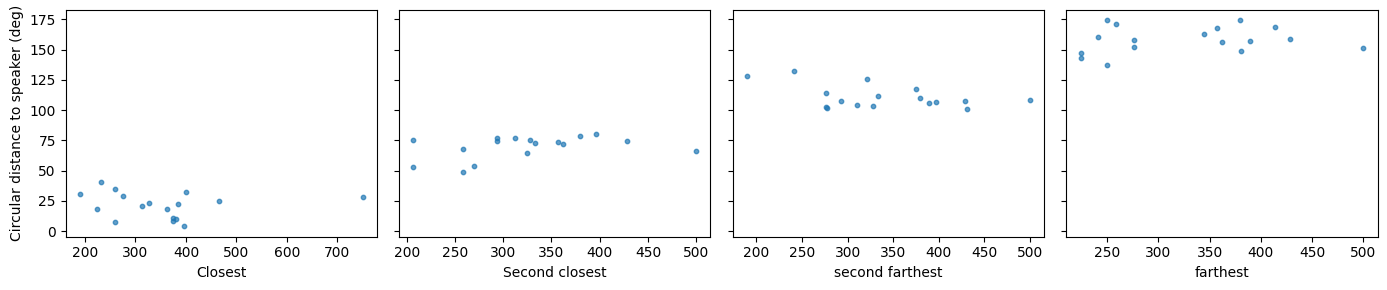

In [8]:
# peak fr for all soundsources
preferred = np.array(comb_table['HDAngle'])
speakers = np.array(list(speaker_position.values()))

# retrieve the cirular distance form the preferred direction to the speakers
diff = preferred[:, None] - speakers[None,:]
wrapped = (diff+180)%360-180
dist_deg = np.abs(wrapped)

# sort the relative distances so that the first column holds the smallest distance and the last column the furthest
idx_sorted = np.argsort(dist_deg, axis=1)
dist_sorted = np.take_along_axis(dist_deg, idx_sorted, axis=1)
# also sort the speakers so we don't lose track
speakers_sorted = np.take_along_axis(
    speakers[None,:], idx_sorted, axis=1
)
# retrieve the max response for each psth and sort as we did with the relative distance to the speakers
resp_peak_fr = np.array([
    np.max(new_rate[:,resp_window,i], axis=1) for i in range(0,4)
]).T
resp_peak_sorted = np.take_along_axis(resp_peak_fr, idx_sorted, axis=1)

fig, axes = plt.subplots(1,4, figsize=(14,3), sharey=True)

xlab = ['Closest', 'Second closest', 'second farthest', 'farthest']
for i, key in enumerate(speaker_position):
    axes[i].scatter(
        resp_peak_sorted[:,i],
        dist_sorted[:, i],
        s=10,
        alpha=0.7
    )
    axes[i].set_xlabel(xlab[i])
    if i == 0:
        axes[i].set_ylabel("Circular distance to speaker (deg)")

plt.tight_layout()
plt.show()



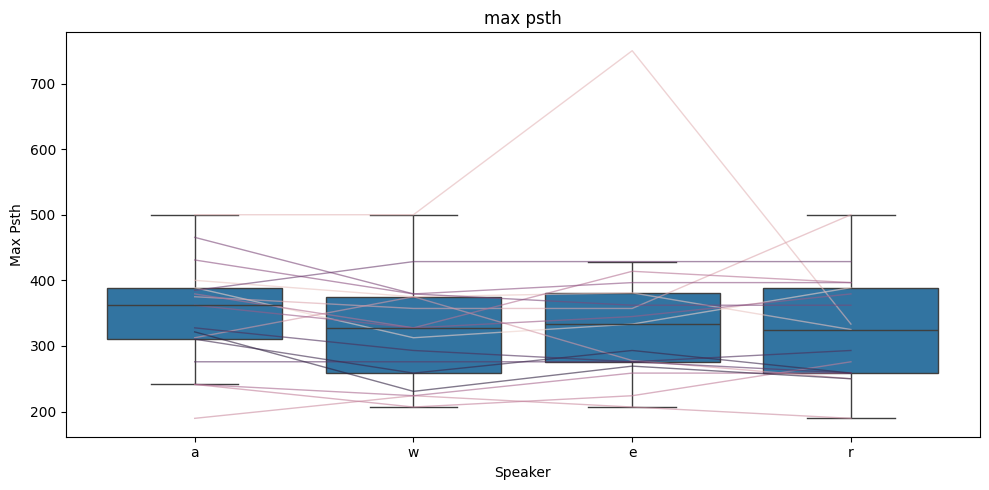

Friedman Chi^2: 6.25; p: 0.10


In [9]:


resp_peak_df = pd.DataFrame(resp_peak_fr, columns=list('awer'))
long_df = resp_peak_df.reset_index().melt(
    id_vars='index',
    var_name='speaker',
    value_name='max_psth'
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=long_df,
    x="speaker",
    y='max_psth',
    fliersize=0
    )

sns.lineplot(
    data=long_df,
    x="speaker",
    y="max_psth",
    hue="index",
    estimator=None,
    linewidth=1,
    alpha=0.6,
    legend=False
)

plt.xlabel("Speaker")
plt.ylabel("Max Psth")
plt.title('max psth')
plt.tight_layout()
plt.show()

# implement friedman test (non parametric Anova to compare the between the speaker responses but respecting the across within-cell pairing)
stat, p = friedmanchisquare(resp_peak_df['a'], resp_peak_df['w'], resp_peak_df['e'], resp_peak_df['r'])
print(
    f"Friedman Chi^2: {stat:.2f}; p: {p:.2f}"
    )


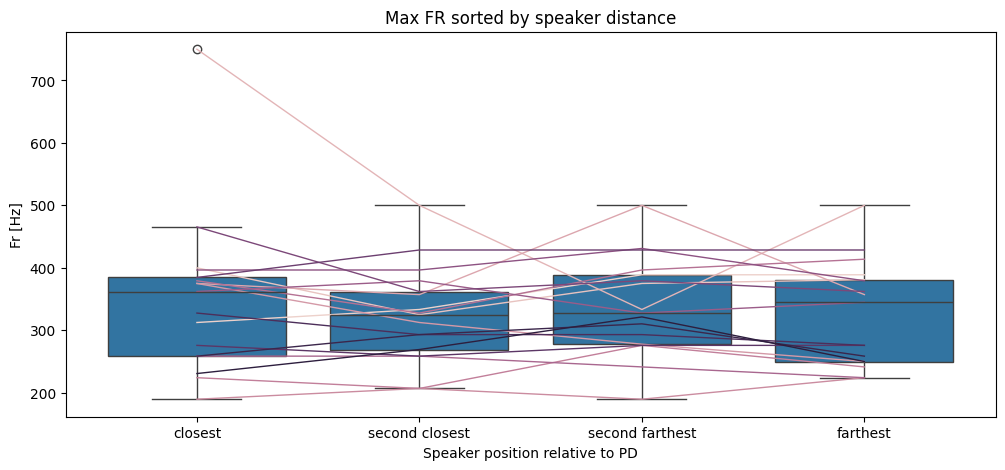

Friedman Chi square: 2.33, p = 0.51
93 vs 178: corrected p = 0.40
93 vs 272: corrected p = 0.83
93 vs 356: corrected p = 0.69
178 vs 272: corrected p = 0.40
178 vs 356: corrected p = 0.86
272 vs 356: corrected p = 0.40


In [10]:
# max psth (firing rate) sorted by distance

fr_resp_sorted = np.take_along_axis(
    resp_peak_fr, idx_sorted, axis=1
)
fr_resp_df_sort = pd.DataFrame(fr_resp_sorted, columns=['closest', 'second_closest', 'second_farthest', 'farthest']).reset_index().melt(id_vars='index', var_name='speaker', value_name='fr_psth')

plt.figure(figsize=(12, 5))
plt.title("Max FR sorted by speaker distance")
ax = sns.boxplot(data=fr_resp_df_sort, x='speaker', y='fr_psth')
ax.set_xticks([0,1,2,3])
ax.set_ylabel("Fr [Hz]")
ax.set_xlabel("Speaker position relative to PD")
ax.set_xticklabels(['closest', 'second closest', 'second farthest', 'farthest'])
sns.lineplot(data=fr_resp_df_sort, x='speaker', y='fr_psth', hue='index', linewidth=1, legend=False)
plt.show()

# corresponding statistics printed
fr_stat, fr_p = friedmanchisquare(fr_resp_sorted[:, 0], fr_resp_sorted[:, 1], fr_resp_sorted[:, 2], fr_resp_sorted[:, 3])
print(f"Friedman Chi square: {fr_stat:.2f}, p = {fr_p:.2f}")

conds = [0,1,2,3]
fr_p_list = []
for c1, c2 in itertools.combinations(conds, 2):
    stat, p = wilcoxon(fr_resp_sorted[:, c1], fr_resp_sorted[:, c2])
    fr_p_list.append(p)

corrected_sorted_fr_p = false_discovery_control(fr_p_list)
for a in zip(itertools.combinations(speakers, 2), corrected_sorted_fr_p):
    print(f"{a[0][0]} vs {a[0][1]}: corrected p = {a[1]:.2f}")

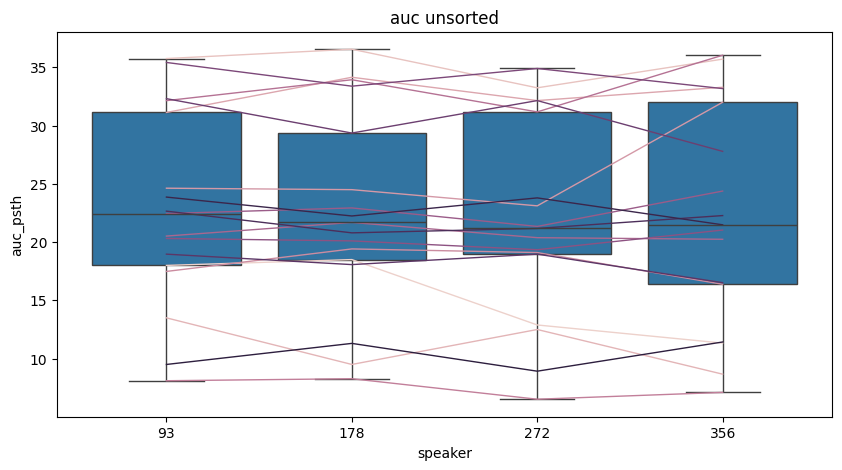

7.517647058823513 0.05710675306069067
93 vs 178: corrected p = 0.96
93 vs 272: corrected p = 0.08
93 vs 356: corrected p = 0.69
178 vs 272: corrected p = 0.67
178 vs 356: corrected p = 0.69
272 vs 356: corrected p = 0.96


In [11]:
# calculate the integral over the bins
auc_resp = (new_rate[:, resp_window, :] * time_bin).sum(axis=1)
auc_resp_df = pd.DataFrame(auc_resp, columns=['a', 'w', 'e', 'r']).reset_index().melt(id_vars='index', var_name='speaker', value_name='auc_psth')
auc_stat, auc_p = friedmanchisquare(auc_resp[:,0],auc_resp[:,1],auc_resp[:,2],auc_resp[:,3])
plt.figure(figsize=(10,5))
plt.title('auc unsorted')
ax = sns.boxplot(data=auc_resp_df,x='speaker', y='auc_psth')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(speakers)
sns.lineplot(data=auc_resp_df, x='speaker', y='auc_psth', hue='index', linewidth=1, legend=False)
plt.show()
print(auc_stat, auc_p)

conds = [0,1,2,3]
auc_p_list = []

for c1, c2 in itertools.combinations(conds, 2):
    stat, p = wilcoxon(auc_resp[:, c1], auc_resp[:, c2])
    auc_p_list.append(p)

corrected_auc_p = false_discovery_control(auc_p_list)
for a in zip(itertools.combinations(speakers,2), corrected_auc_p):
    print(f"{a[0][0]} vs {a[0][1]}: corrected p = {a[1]:.2f}")


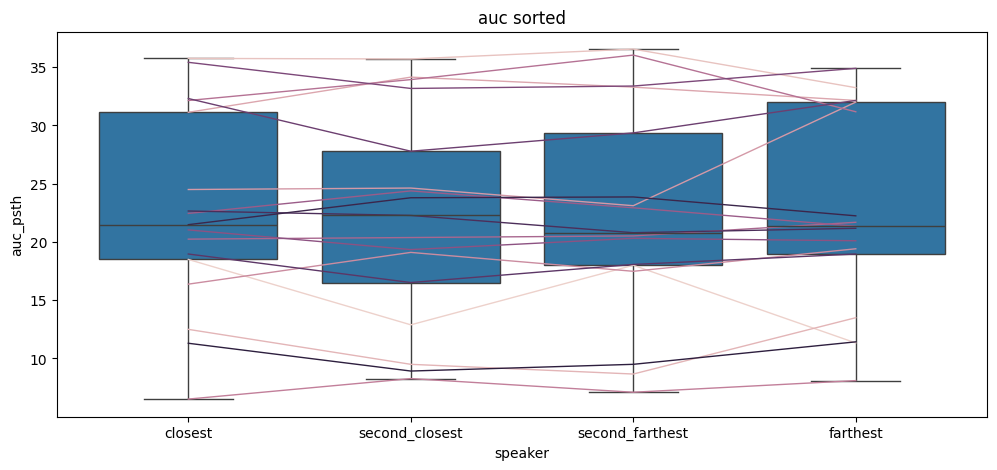

Friedman Test p: 0.94
closest vs second_closest: corrected p = 0.89
closest vs second_farthest: corrected p = 0.89
closest vs farthest: corrected p = 0.89
second_closest vs second_farthest: corrected p = 0.89
second_closest vs farthest: corrected p = 0.89
second_farthest vs farthest: corrected p = 0.89


In [12]:

# do it again with the speakers sorted by distance to PD
auc_resp_sorted = np.take_along_axis(
    auc_resp, idx_sorted, axis=1
)
auc_resp_df_sort = pd.DataFrame(auc_resp_sorted, columns=['closest', 'second_closest', 'second_farthest', 'farthest']).reset_index().melt(id_vars='index', var_name='speaker', value_name='auc_psth')
plt.figure(figsize=(12,5))
plt.title('auc sorted')
ax = sns.boxplot(data=auc_resp_df_sort,x='speaker', y='auc_psth')
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['closest', 'second_closest', 'second_farthest', 'farthest'])
sns.lineplot(data=auc_resp_df_sort, x='speaker', y='auc_psth', hue='index', linewidth=1, legend=False)
plt.show()

auc_stat, auc_p = friedmanchisquare(auc_resp_sorted[:,0],auc_resp_sorted[:,1],auc_resp_sorted[:,2],auc_resp_sorted[:,3])
print(f"Friedman Test p: {auc_p:.2f}")
auc_sort_p_list = []
for c1, c2 in itertools.combinations(conds, 2):
    stat, p = wilcoxon(auc_resp_sorted[:, c1], auc_resp_sorted[:, c2]) 
    auc_sort_p_list.append(p)

corrected_auc_sort_p = false_discovery_control(auc_sort_p_list)
for a in zip(itertools.combinations(['closest', 'second_closest', 'second_farthest', 'farthest'],2), corrected_auc_sort_p):
    print(f"{a[0][0]} vs {a[0][1]}: corrected p = {a[1]:.2f}")

Computation of correlations for each cell

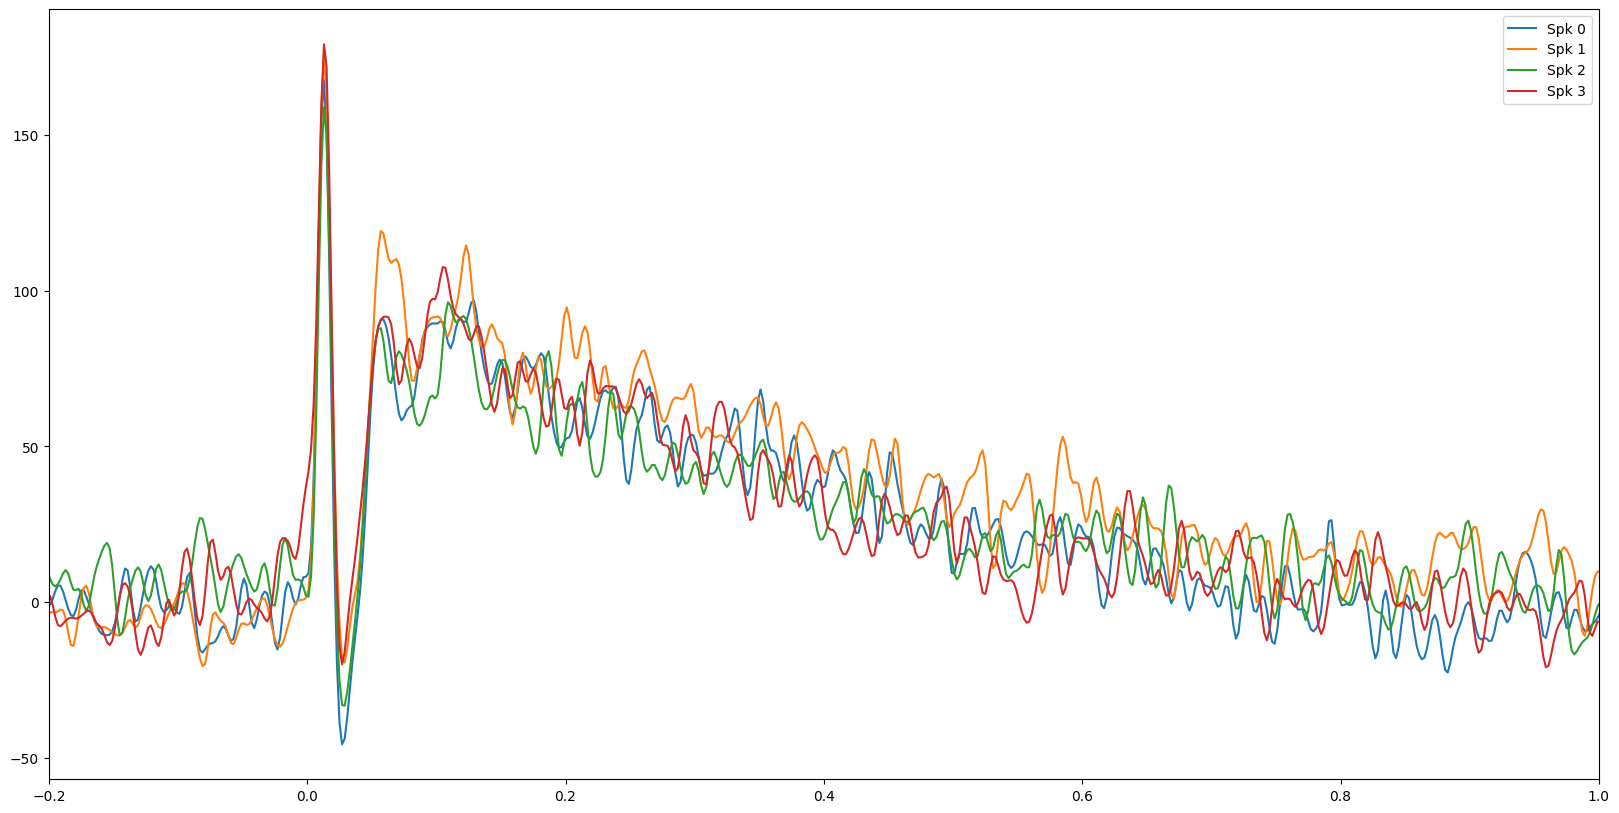

In [20]:
# baseline subtract new_rate first
baseline_time_idx= (bins_plot > -1000) & (bins_plot <0)
baseline_mean = new_rate[:, baseline_time_idx, :]. mean(axis=1, keepdims=True)
new_rate_bs = new_rate - baseline_mean

sigma = 2
new_rate_bs_smooth = gaussian_filter1d(new_rate_bs, sigma=sigma, axis=1)
# slice data for correlations
response_data = new_rate_bs_smooth[:, resp_window, :]

cell = 1

plt.figure(figsize=(20,10))
for speaker in range(4):
    plt.plot(bins_plot/1000,new_rate_bs_smooth[cell,:, speaker], label=f"Spk {speaker}")
    plt.xlim(-0.2, 1)

plt.legend()
plt.show()

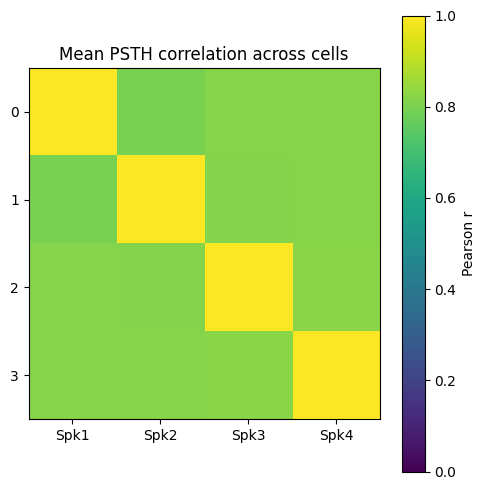

In [21]:

n_cells = response_data.shape[0]
n_speakers = response_data.shape[2]

corr_all = np.zeros((n_cells, n_speakers, n_speakers))

for cell in range(n_cells):
    corr_all[cell] = np.corrcoef(response_data[cell].T)

mean_corr_matrix = corr_all.mean(axis=0)
fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(mean_corr_matrix, vmin=0, vmax=1, cmap='viridis')

ax.set_xticks(range(4))
ax.set_yticks(range(4))

ax.set_xticklabels(['Spk1', 'Spk2', 'Spk3', 'Spk4'])
ax.set_xticklabels(['Spk1', 'Spk2', 'Spk3', 'Spk4'])

ax.set_title('Mean PSTH correlation across cells')

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson r')

plt.tight_layout()
plt.show()


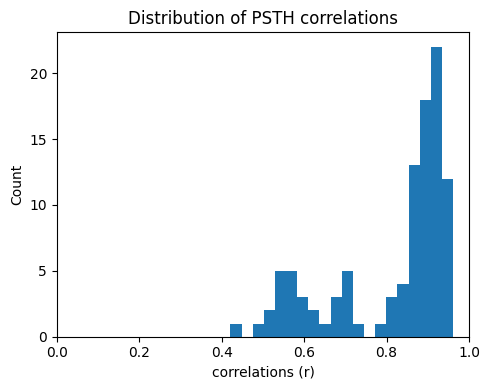

In [22]:

# extract the unique correlations per cell
triu_idx = np.triu_indices(n_speakers, k=1)

corr_pairs = corr_all[:, triu_idx[0], triu_idx[1]]
corr_values = corr_pairs.flatten()

fig, ax = plt.subplots(figsize=(5,4))

ax.hist(corr_values, bins=20)
ax.set_xlabel("correlations (r)")
ax.set_ylabel("Count")
ax.set_title("Distribution of PSTH correlations")

ax.set_xlim(0,1)

plt.tight_layout()
plt.show()

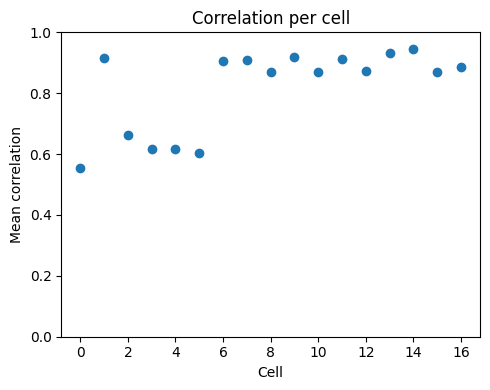

In [23]:
mean_corr_per_cell = corr_pairs.mean(axis=1)

fig, ax = plt.subplots(figsize=(5,4))

ax.scatter(np.arange(len(mean_corr_per_cell)), mean_corr_per_cell)

ax.set_xlabel('Cell')
ax.set_ylabel('Mean correlation')
ax.set_title('Correlation per cell')

ax.set_ylim(0,1)

plt.tight_layout()
plt.show()

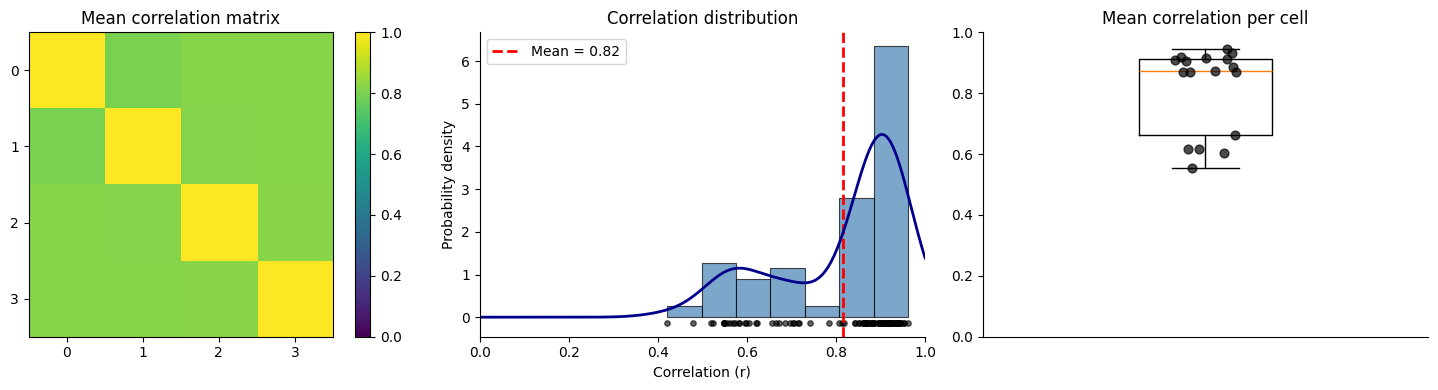

Mean correlation: 0.815 ± 0.142


In [24]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

# heatmap
im = axes[0].imshow(mean_corr_matrix, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title('Mean correlation matrix')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))

plt.colorbar(im, ax=axes[0])

# histogram bins
bins = np.histogram_bin_edges(corr_values, bins='fd')

# histogram
axes[1].hist(corr_values,
             bins=bins,
             density=True,
             alpha=0.7,
             color='steelblue',
             edgecolor='black',
             linewidth=0.8)

# mean line
mean_val = np.mean(corr_values)
axes[1].axvline(mean_val,
                color='red',
                linestyle='--',
                linewidth=2,
                label=f'Mean = {mean_val:.2f}')

# KDE curve (smooth distribution)
x = np.linspace(0, 1, 500)
kde = gaussian_kde(corr_values)
axes[1].plot(x,
             kde(x),
             color='darkblue',
             linewidth=2)

# Rug scatter (individual datapoints)
ymin, ymax = axes[1].get_ylim()
rug_y = ymin - 0.02 * (ymax - ymin)

axes[1].scatter(corr_values,
                np.full_like(corr_values, rug_y),
                color='black',
                s=15,
                alpha=0.6,
                clip_on=False)

# formatting
axes[1].set_xlabel("Correlation (r)")
axes[1].set_ylabel("Probability density")
axes[1].set_title('Correlation distribution')
axes[1].legend()
axes[1].set_xlim(0, 1)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# boxplot
x_center = 1
jitter_strength = 0.08
x_jittered = x_center + np.random.uniform(-jitter_strength,
                                          jitter_strength,
                                          size=len(mean_corr_per_cell))

axes[2].boxplot(mean_corr_per_cell, widths=0.3, showfliers=False)
axes[2].scatter(x_jittered,mean_corr_per_cell, color='black', alpha=0.7, s=40, zorder=3)
axes[2].set_xticks([])
axes[2].set_title('Mean correlation per cell')
axes[2].set_ylim(0,1)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
mean_corr = corr_values.mean()
std_corr = corr_values.std()

print(f"Mean correlation: {mean_corr:.3f} ± {std_corr:.3f}")

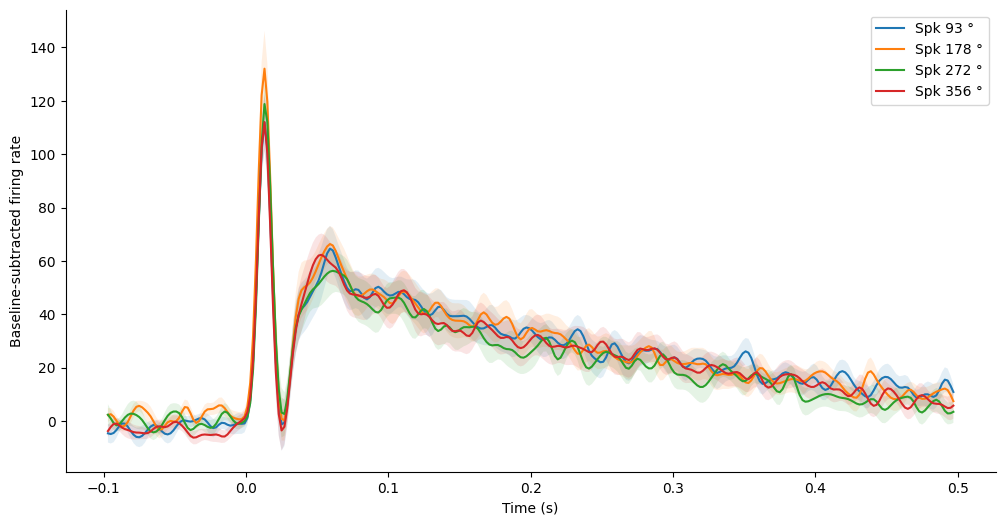

In [25]:
mean_psth = new_rate_bs_smooth.mean(axis=0)
sem_psth  = new_rate_bs_smooth.std(axis=0) / np.sqrt(new_rate_bs_smooth.shape[0])
plot_resp_show = np.arange(resp_window[0]-50, resp_window[-1]+100, step=1)

fig, ax = plt.subplots(figsize=(12,6))

x = bins_plot[plot_resp_show]/1000

for idx, spk in enumerate(speakers):
    y = mean_psth[plot_resp_show, idx]
    sem = sem_psth[plot_resp_show, idx]

    ax.plot(x, y, label=f"Spk {spk} °")
    ax.fill_between(x, y-sem, y+sem, alpha=0.12)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Baseline-subtracted firing rate")
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

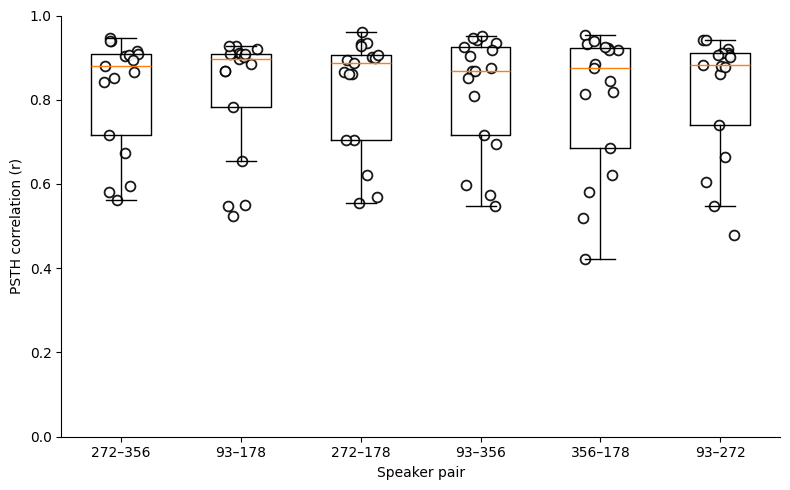

Friedman chi² = 2.176, p = 0.824

Pairwise comparisons:
272–356 vs 93–178: p = 0.890
272–356 vs 272–178: p = 0.431
272–356 vs 93–356: p = 0.678
272–356 vs 356–178: p = 0.284
272–356 vs 93–272: p = 0.747
93–178 vs 272–178: p = 0.818
93–178 vs 93–356: p = 0.963
93–178 vs 356–178: p = 0.378
93–178 vs 93–272: p = 0.854
272–178 vs 93–356: p = 0.854
272–178 vs 356–178: p = 0.159
272–178 vs 93–272: p = 0.854
93–356 vs 356–178: p = 0.431
93–356 vs 93–272: p = 0.927
356–178 vs 93–272: p = 0.712


In [28]:
speaker_keys = list(stim_keys)  # e.g. ['a','e','r','w']
speaker_position = {"a": 93, "w": 178, "e": 272, "r": 356}
speaker_angles_deg = np.array([speaker_position[k] for k in speaker_keys])

n_cells, n_spk, _ = corr_all.shape
i_idx, j_idx = np.triu_indices(len(speaker_keys), k=1)

pair_labels = [f"{speaker_angles_deg[i]}–{speaker_angles_deg[j]}"
               for i, j in zip(i_idx, j_idx)]
pair_distances = np.abs((speaker_angles_deg[i_idx] - speaker_angles_deg[j_idx] + 180) % 360 - 180)

sort_idx = np.argsort(pair_distances)

corr_pairs = corr_pairs[:, sort_idx]
pair_labels = [pair_labels[i] for i in sort_idx]

# corr_pairs already exists:
# shape = (n_cells, 6)
# columns correspond to pair_labels order
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, ax = plt.subplots(figsize=(8,5))

n_pairs = corr_pairs.shape[1]
x_positions = np.arange(n_pairs)

# Boxplots
ax.boxplot([corr_pairs[:, i] for i in range(n_pairs)],
           positions=x_positions,
           widths=0.5,
           showfliers=False)

# Scatter overlay (each point = one cell)
for i in range(n_pairs):
    
    jitter = np.random.uniform(-0.15, 0.15, size=corr_pairs.shape[0])
    
    ax.scatter(np.full(corr_pairs.shape[0], x_positions[i]) + jitter,
               corr_pairs[:, i],
               facecolors='white',
               edgecolors='black',
               s=50,
               linewidth=1.3,
               alpha=0.9)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(pair_labels)

ax.set_ylabel("PSTH correlation (r)")
ax.set_xlabel("Speaker pair")

ax.set_ylim(0,1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(*[corr_pairs[:, i] for i in range(n_pairs)])

print(f"Friedman chi² = {stat:.3f}, p = {p:.3f}")

from scipy.stats import wilcoxon
import itertools

print("\nPairwise comparisons:")

for i, j in itertools.combinations(range(n_pairs), 2):
    
    stat, p = wilcoxon(corr_pairs[:, i], corr_pairs[:, j])
    
    print(f"{pair_labels[i]} vs {pair_labels[j]}: p = {p:.3f}")